<a href="https://colab.research.google.com/github/soonyz06/Factor_Tangency/blob/main/Factor_Tangency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We compare equal-weight, inverse-volatility, MVO, Ridge, HMM, and meta-allocation factor portfolios using daily returns. Models are estimated on rolling five-year windows, refit quarterly, and rebalanced monthly. Ridge forecasts next-month daily moments, while HMM probabilities update daily and are propagated and moment-matched into next-month daily moments. These estimates feed return-to-volatility or MVO allocation. Meta-Ridge and meta-MVO allocate across the resulting base portfolios using their realized performance. Performance is evaluated using return, volatility, Sharpe, skewness, drawdown, CAGR, and stationary-block bootstrap Sharpe distributions. Transaction costs are excluded.


#Load


In [ ]:
import pandas as pd
from statsmodels.tsa.api import VAR
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
#!pip install hmmlearn

In [ ]:
df = pd.read_csv("F-F_Research_Data_5_Factors_2x3_daily.csv", skiprows=4, skipfooter=2, engine="python")
df = df.rename(columns={df.columns[0]:"date"})
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

df2 = pd.read_csv("F-F_Momentum_Factor_daily.csv", skiprows=13, skipfooter=2, engine="python")
df2 = df2.rename(columns={df2.columns[0]:"date"})
df2["date"] = pd.to_datetime(df2["date"], format="%Y%m%d")
df = df.merge(df2, on="date", how="inner").dropna().set_index('date') #no null
display(df.head())
df.describe()

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
date,,,,,,,
1963-07-01,-0.67,0.00,-0.33,-0.01,0.16,0.01,-0.23
1963-07-02,0.79,-0.26,0.26,-0.07,-0.20,0.01,0.45
1963-07-03,0.63,-0.17,-0.10,0.18,-0.34,0.01,0.39
1963-07-05,0.40,0.08,-0.27,0.09,-0.34,0.01,0.06
1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01,-0.45


,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
count,15876.000000,15876.000000,15876.000000,15876.000000,15876.000000,15876.000000,15876.000000
mean,0.028974,0.006283,0.014948,0.012543,0.011963,0.017164,0.028744
std,1.021590,0.551083,0.587706,0.412699,0.385651,0.012677,0.789551
min,-17.440000,-11.150000,-5.030000,-2.960000,-5.300000,0.000000,-14.390000
25%,-0.420000,-0.280000,-0.240000,-0.180000,-0.180000,0.010000,-0.250000
50%,0.050000,0.020000,0.010000,0.010000,0.010000,0.020000,0.060000
75%,0.510000,0.310000,0.260000,0.190000,0.200000,0.020000,0.370000
max,11.360000,6.080000,6.730000,4.570000,2.470000,0.060000,7.120000


#Model

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Equal Weight,0.0004,0.0004,0.0004,1.1879,-0.7170,-0.0014
Trailing IV,0.0004,0.0004,0.0003,1.1768,-0.4919,-0.0014
Trailing MVO,0.0003,0.0003,0.0004,0.8474,-0.4172,-0.0012
Ridge R/V,0.0000,0.0000,0.0006,0.0764,-0.5920,-0.0063
Ridge MVO,0.0001,0.0001,0.0004,0.2692,-0.5117,-0.0036
HMM R/V,0.0004,0.0004,0.0006,0.6277,-0.7084,-0.0022
HMM MVO,0.0003,0.0003,0.0003,0.7764,-0.5863,-0.0021
Meta Ridge,0.0001,0.0001,0.0002,0.3812,-1.6148,-0.0009
Meta MVO,0.0002,0.0002,0.0002,1.1510,-0.4294,-0.0006


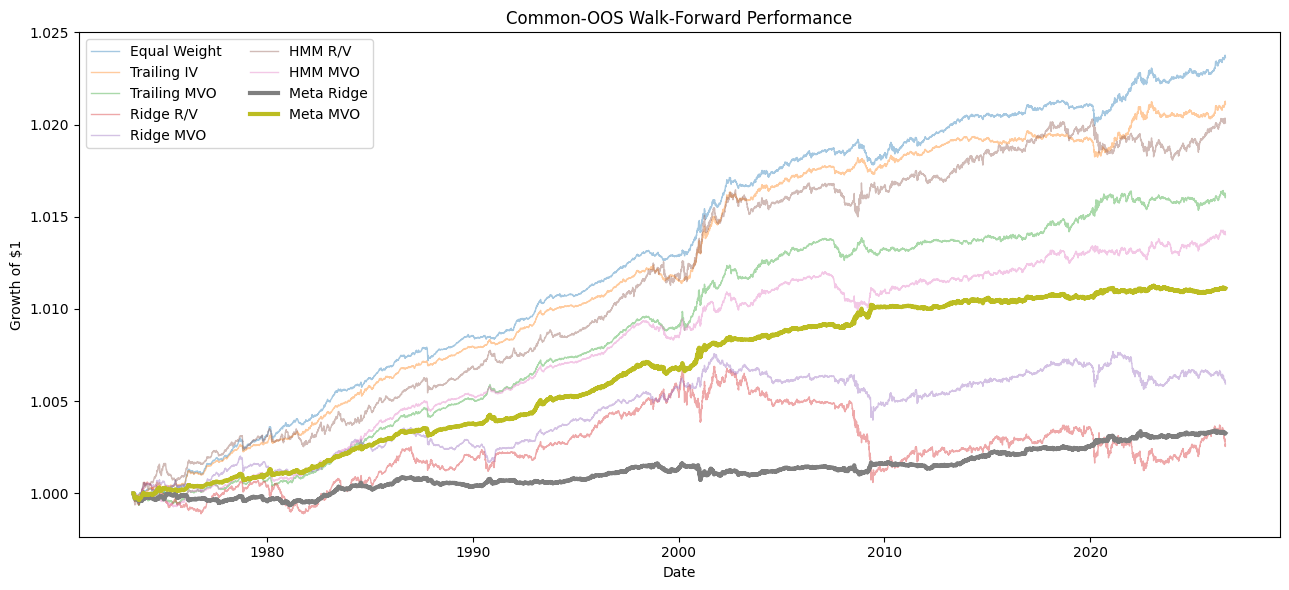

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Equal Weight,1.1879,1.1907,0.8533,1.1857,1.5311,1.0000
Trailing IV,1.1768,1.1799,0.8494,1.1803,1.5106,1.0000
Trailing MVO,0.8474,0.8499,0.5310,0.8473,1.1775,1.0000
Ridge R/V,0.0764,0.0784,-0.2217,0.0773,0.3872,0.6938
Ridge MVO,0.2692,0.2720,-0.0338,0.2718,0.5789,0.9606
HMM R/V,0.6277,0.6269,0.3346,0.6251,0.9158,1.0000
HMM MVO,0.7764,0.7761,0.4520,0.7768,1.1084,1.0000
Meta Ridge,0.3812,0.3852,0.0382,0.3843,0.7337,0.9880
Meta MVO,1.1510,1.1517,0.8094,1.1538,1.4880,1.0000


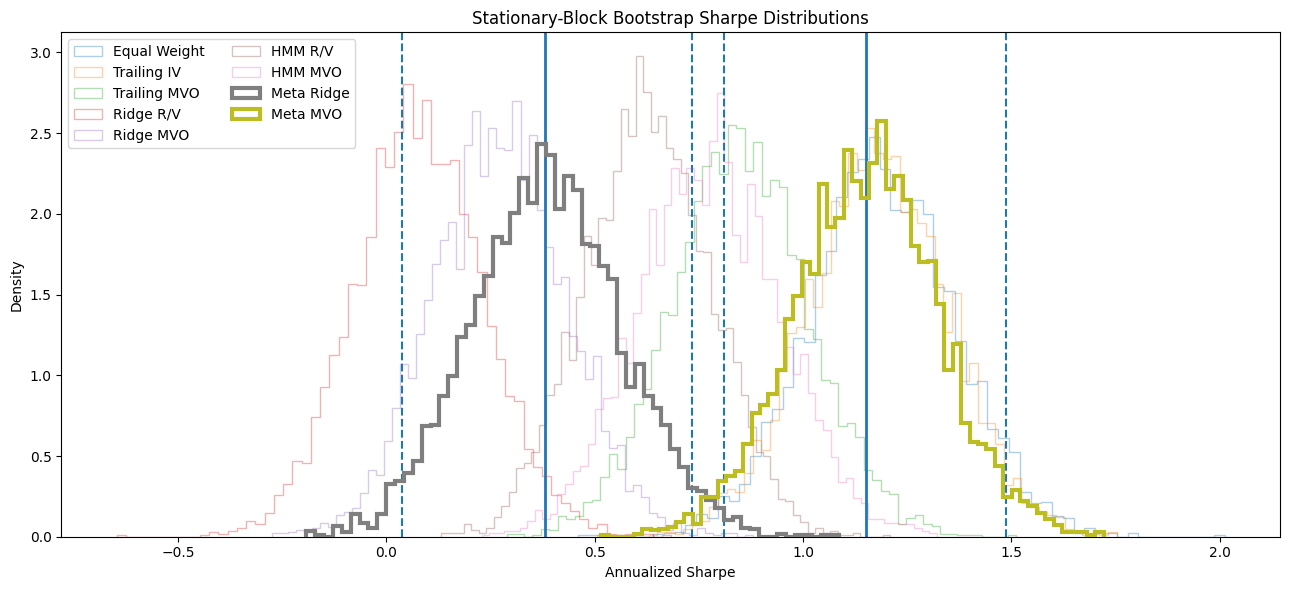

In [171]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from hmmlearn.hmm import GaussianHMM

FACTOR_COLS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
RETURNS_ARE_PERCENT = True
TRAIL_DAYS = 252 * 5
FEATURE_HORIZONS = [21, 63, 126, 252, 756, 1260]
RIDGE_WINDOW_MONTHS, MIN_RIDGE_MONTHS, RIDGE_ALPHA = 60, 48, 10.0
HMM_STATES, HMM_WINDOW, HMM_FORECAST_DAYS, HMM_N_ITER = 3, 252 * 5, 21, 500
META_WINDOW_DAYS, META_MIN_DAYS = 252 * 5, 63
META_HORIZONS, META_FORECAST_DAYS, META_RIDGE_ALPHA = [5, 21, 63], 21, 10.0
N_BOOT, BLOCK_LENGTH, SEED = 5000, 20, 42

x = df.copy()
if "date" in x.columns:
    x["date"] = pd.to_datetime(x["date"])
    x = x.set_index("date")
x.index = pd.to_datetime(x.index)
r = x[FACTOR_COLS].apply(pd.to_numeric, errors="coerce").sort_index().dropna()
if RETURNS_ARE_PERCENT:
    r /= 100

def l1_normalize(w):
    d = np.abs(w).sum()
    return w / d if d > 0 else np.zeros_like(w)

def metrics(r):
    r = pd.Series(r).dropna()
    arithmetic = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    sharpe = arithmetic / vol if vol > 0 else np.nan
    wealth = (1 + r).cumprod()
    years = len(r) / 252
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    dd = wealth / wealth.cummax() - 1
    return pd.Series({
        "CAGR": cagr, "Arithmetic Return": arithmetic,
        "Volatility": vol, "Sharpe": sharpe,
        "Skew": skew(r, bias=False), "Max Drawdown": dd.min()
    })

def stationary_bootstrap_indices(T, block_length, rng):
    p = 1 / block_length
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(T)
    for t in range(1, T):
        idx[t] = rng.integers(T) if rng.random() < p else (idx[t-1] + 1) % T
    return idx

def sharpe_ratio(r):
    sd = np.std(r, ddof=1)
    return np.mean(r) / sd * np.sqrt(252) if sd > 0 else np.nan

periods = r.index.to_period("M")
monthly_mu = r.groupby(periods).mean()
monthly_sd = r.groupby(periods).std()
ridge_mu_target = monthly_mu.shift(-1)
ridge_sd_target = np.log(monthly_sd.clip(lower=1e-12).shift(-1))

feature_dict = {}
for f in FACTOR_COLS:
    F = {}
    for h in FEATURE_HORIZONS:
        mu = r[f].rolling(h).mean()
        sd = r[f].rolling(h).std()
        F[f"mu_{h}"] = mu
        F[f"sd_{h}"] = sd
        F[f"mu_sd_{h}"] = mu / sd
    feature_dict[f] = pd.DataFrame(F).groupby(periods).last()

ridge_mu_models = {f: None for f in FACTOR_COLS}
ridge_sd_models = {f: None for f in FACTOR_COLS}

def refit_ridge(current_month):
    for f in FACTOR_COLS:
        X = feature_dict[f]
        months = [m for m in X.index if m + 1 < current_month][-RIDGE_WINDOW_MONTHS:]

        tm = X.reindex(months).copy()
        tm["y"] = ridge_mu_target[f].reindex(months)
        tm = tm.replace([np.inf, -np.inf], np.nan).dropna()

        ts = X.reindex(months).copy()
        ts["y"] = ridge_sd_target[f].reindex(months)
        ts = ts.replace([np.inf, -np.inf], np.nan).dropna()

        ridge_mu_models[f] = None
        ridge_sd_models[f] = None

        if len(tm) >= MIN_RIDGE_MONTHS:
            ridge_mu_models[f] = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
            ridge_mu_models[f].fit(tm.drop(columns="y"), tm["y"])

        if len(ts) >= MIN_RIDGE_MONTHS:
            ridge_sd_models[f] = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
            ridge_sd_models[f].fit(ts.drop(columns="y"), ts["y"])

def ridge_forecast(info_month):
    mu, sd = [], []
    for f in FACTOR_COLS:
        if ridge_mu_models[f] is None or ridge_sd_models[f] is None or info_month not in feature_dict[f].index:
            return None
        X = feature_dict[f].loc[[info_month]].replace([np.inf, -np.inf], np.nan)
        if X.isna().any(axis=None):
            return None
        mu.append(ridge_mu_models[f].predict(X)[0])
        sd.append(np.exp(ridge_sd_models[f].predict(X)[0]))
    return np.asarray(mu), np.asarray(sd)

def fit_hmm(hist):
    mean, sd = hist.mean().values, hist.std().values
    sd = np.where(sd > 0, sd, 1)
    X = (hist.values - mean) / sd

    model = GaussianHMM(
        n_components=HMM_STATES, covariance_type="full",
        n_iter=HMM_N_ITER, random_state=SEED
    )
    model.fit(X)

    D = np.diag(sd)
    means = np.asarray([mean + sd * m for m in model.means_])
    covs = np.asarray([D @ c @ D for c in model.covars_])

    return {
        "model": model,
        "alpha": model.predict_proba(X)[-1],
        "mean": mean, "sd": sd,
        "means": means, "covs": covs
    }

def update_hmm(state, obs):
    model = state["model"]
    z = (obs - state["mean"]) / state["sd"]
    prior = state["alpha"] @ model.transmat_
    ll = np.asarray([
        multivariate_normal.logpdf(
            z, mean=model.means_[k],
            cov=model.covars_[k], allow_singular=True
        )
        for k in range(HMM_STATES)
    ])
    logp = np.log(np.clip(prior, 1e-300, None)) + ll
    state["alpha"] = np.exp(logp - logsumexp(logp))

def hmm_forecast(state):
    p = state["alpha"].copy()
    mus, seconds = [], []

    for _ in range(HMM_FORECAST_DAYS):
        p = p @ state["model"].transmat_
        mu = np.sum(p[:, None] * state["means"], axis=0)
        second = sum(
            p[k] * (state["covs"][k] + np.outer(state["means"][k], state["means"][k]))
            for k in range(HMM_STATES)
        )
        mus.append(mu)
        seconds.append(second)

    mu = np.mean(mus, axis=0)
    cov = np.mean(seconds, axis=0) - np.outer(mu, mu)
    cov = (cov + cov.T) / 2
    eig = np.linalg.eigvalsh(cov)
    if eig.min() < 1e-12:
        cov += np.eye(len(mu)) * (1e-12 - eig.min())
    return mu, cov

BASE_STRATEGIES = [
    "Equal Weight", "Trailing IV", "Trailing MVO",
    "Ridge R/V", "Ridge MVO", "HMM R/V", "HMM MVO"
]

rets = pd.DataFrame(np.nan, index=r.index, columns=BASE_STRATEGIES)
months = sorted(periods.unique())
last_ridge_quarter = last_hmm_quarter = None
hmm_state = None

for month in months:
    dates = r.index[periods == month]
    if len(dates) == 0:
        continue

    pos = r.index.get_loc(dates[0])
    if pos == 0:
        continue

    info_date = r.index[pos - 1]
    info_month = month - 1
    hist = r.loc[:info_date].tail(TRAIL_DAYS)
    R = r.loc[dates, FACTOR_COLS].values
    quarter = (month.year, month.quarter)

    w = np.ones(len(FACTOR_COLS)) / len(FACTOR_COLS)
    rets.loc[dates, "Equal Weight"] = R @ w

    if len(hist) >= TRAIL_DAYS:
        mu = hist.mean().values
        sd = hist.std().values
        cov = hist.cov().values + np.eye(len(FACTOR_COLS)) * 1e-10

        w_iv = (1 / sd) / np.sum(1 / sd)
        w_mvo = l1_normalize(np.linalg.pinv(cov) @ mu)

        rets.loc[dates, "Trailing IV"] = R @ w_iv
        rets.loc[dates, "Trailing MVO"] = R @ w_mvo

    if quarter != last_ridge_quarter:
        refit_ridge(month)
        last_ridge_quarter = quarter

    rf = ridge_forecast(info_month)

    if rf is not None and len(hist) >= TRAIL_DAYS:
        mu_hat, sd_hat = rf
        corr = hist.corr().values
        D = np.diag(sd_hat)
        cov_hat = D @ corr @ D + np.eye(len(FACTOR_COLS)) * 1e-10

        w_rv = l1_normalize(mu_hat / sd_hat)
        w_mvo = l1_normalize(np.linalg.pinv(cov_hat) @ mu_hat)

        rets.loc[dates, "Ridge R/V"] = R @ w_rv
        rets.loc[dates, "Ridge MVO"] = R @ w_mvo

    if quarter != last_hmm_quarter and len(hist) >= HMM_WINDOW:
        hmm_state = fit_hmm(hist.tail(HMM_WINDOW))
        last_hmm_quarter = quarter

    if hmm_state is not None:
        mu_hat, cov_hat = hmm_forecast(hmm_state)
        sd_hat = np.sqrt(np.diag(cov_hat))

        w_rv = l1_normalize(mu_hat / sd_hat)
        w_mvo = l1_normalize(np.linalg.pinv(cov_hat) @ mu_hat)

        rets.loc[dates, "HMM R/V"] = R @ w_rv
        rets.loc[dates, "HMM MVO"] = R @ w_mvo

        for obs in R:
            update_hmm(hmm_state, obs)

base_rets = rets[BASE_STRATEGIES].replace([np.inf, -np.inf], np.nan)
base_common = base_rets.dropna()

meta_features = pd.DataFrame(index=base_common.index)

for s in BASE_STRATEGIES:
    rr = base_common[s]
    meta_features[f"{s}_last"] = rr
    for h in META_HORIZONS:
        meta_features[f"{s}_mu_{h}"] = rr.rolling(h).mean()
        meta_features[f"{s}_sd_{h}"] = rr.rolling(h).std()

meta_targets = pd.DataFrame(index=base_common.index)

for s in BASE_STRATEGIES:
    meta_targets[s] = (
        base_common[s].shift(-1)
        .rolling(META_FORECAST_DAYS).mean()
        .shift(-(META_FORECAST_DAYS - 1))
    )

meta_models = {s: None for s in BASE_STRATEGIES}

def refit_meta(rebalance_date):
    pos = base_common.index.get_loc(rebalance_date)
    end = pos - META_FORECAST_DAYS - 1
    if end < 0:
        return

    eligible = base_common.index[:end + 1][-META_WINDOW_DAYS:]

    for s in BASE_STRATEGIES:
        train = meta_features.loc[eligible].copy()
        train["y"] = meta_targets[s].reindex(eligible)
        train = train.replace([np.inf, -np.inf], np.nan).dropna()

        meta_models[s] = None
        if len(train) >= META_MIN_DAYS:
            model = make_pipeline(StandardScaler(), Ridge(alpha=META_RIDGE_ALPHA))
            model.fit(train.drop(columns="y"), train["y"])
            meta_models[s] = model

def meta_forecast(info_date):
    if info_date not in meta_features.index:
        return None
    X = meta_features.loc[[info_date]].replace([np.inf, -np.inf], np.nan)
    if X.isna().any(axis=None) or any(meta_models[s] is None for s in BASE_STRATEGIES):
        return None
    return np.asarray([meta_models[s].predict(X)[0] for s in BASE_STRATEGIES])

meta_ridge_ret = pd.Series(np.nan, index=base_common.index)
meta_mvo_ret = pd.Series(np.nan, index=base_common.index)
last_meta_quarter = None

for month in sorted(base_common.index.to_period("M").unique()):
    dates = base_common.index[base_common.index.to_period("M") == month]
    if len(dates) == 0:
        continue

    pos = base_common.index.get_loc(dates[0])
    if pos == 0:
        continue

    info_date = base_common.index[pos - 1]
    hist = base_common.loc[:info_date].tail(META_WINDOW_DAYS)

    if len(hist) < META_MIN_DAYS:
        continue

    cov = hist.cov().values + np.eye(len(BASE_STRATEGIES)) * 1e-10
    R = base_common.loc[dates, BASE_STRATEGIES].values

    w_mvo = l1_normalize(np.linalg.pinv(cov) @ hist.mean().values)
    meta_mvo_ret.loc[dates] = R @ w_mvo

    quarter = (month.year, month.quarter)

    if quarter != last_meta_quarter:
        refit_meta(dates[0])
        last_meta_quarter = quarter

    mu_hat = meta_forecast(info_date)

    if mu_hat is not None:
        w_ridge = l1_normalize(np.linalg.pinv(cov) @ mu_hat)
        meta_ridge_ret.loc[dates] = R @ w_ridge

rets = base_common.copy()
rets["Meta Ridge"] = meta_ridge_ret
rets["Meta MVO"] = meta_mvo_ret

META_STRATEGIES = ["Meta Ridge", "Meta MVO"]
STRATEGIES = BASE_STRATEGIES + META_STRATEGIES
common_rets = rets[STRATEGIES].dropna()

if common_rets.empty:
    raise ValueError("No common OOS observations.")

results = pd.DataFrame({s: metrics(common_rets[s]) for s in STRATEGIES}).T
display(results.round(4))

wealth = (1 + common_rets).cumprod()

plt.figure(figsize=(13, 6))
for s in STRATEGIES:
    if s in META_STRATEGIES:
        plt.plot(wealth.index, wealth[s], label=s, linewidth=3, zorder=10)
    else:
        plt.plot(wealth.index, wealth[s], label=s, linewidth=1, alpha=0.4)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Common-OOS Walk-Forward Performance")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

rng = np.random.default_rng(SEED)
R = common_rets.values
boot = np.empty((N_BOOT, len(STRATEGIES)))

for b in range(N_BOOT):
    idx = stationary_bootstrap_indices(len(R), BLOCK_LENGTH, rng)
    sample = R[idx]
    for j in range(len(STRATEGIES)):
        boot[b, j] = sharpe_ratio(sample[:, j])

boot_df = pd.DataFrame(boot, columns=STRATEGIES)

bootstrap_summary = pd.DataFrame({
    "Observed": results["Sharpe"],
    "Bootstrap Mean": boot_df.mean(),
    "2.5%": boot_df.quantile(.025),
    "Median": boot_df.median(),
    "97.5%": boot_df.quantile(.975),
    "P(S > 0)": (boot_df > 0).mean()
})

display(bootstrap_summary.round(4))

plt.figure(figsize=(13, 6))
for s in STRATEGIES:
    vals = boot_df[s].dropna()
    if s in META_STRATEGIES:
        plt.hist(vals, bins=60, density=True, histtype="step", linewidth=3, label=s, zorder=10)
        plt.axvline(vals.quantile(.025), linestyle="--", linewidth=1.5)
        plt.axvline(vals.quantile(.975), linestyle="--", linewidth=1.5)
        plt.axvline(results.loc[s, "Sharpe"], linewidth=2)
    else:
        plt.hist(vals, bins=60, density=True, histtype="step", linewidth=1, alpha=.35, label=s)
plt.xlabel("Annualized Sharpe")
plt.ylabel("Density")
plt.title("Stationary-Block Bootstrap Sharpe Distributions")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()